In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [4]:
# Age: fill missing with median (robust to outliers)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: fill missing with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: too many missing values to fill meaningfully — drop the column,
# but first extract whether a passenger HAD a cabin (may be informative)
df["HasCabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])

# Drop columns that don't help EDA (unique identifiers/text)
df = df.drop(columns=["PassengerId", "Ticket", "Name"])

# Confirm no missing values remain
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

In [5]:
df.describe(include="all")

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
count,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891,891.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,NaN
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,646,NaN
mean,0.383838,2.308642,NaN,29.361582,0.523008,0.381594,32.204208,NaN,0.228956
std,0.486592,0.836071,NaN,13.019697,1.102743,0.806057,49.693429,NaN,0.420397
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,0.000000
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400,NaN,0.000000
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,0.000000
75%,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000,NaN,0.000000


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


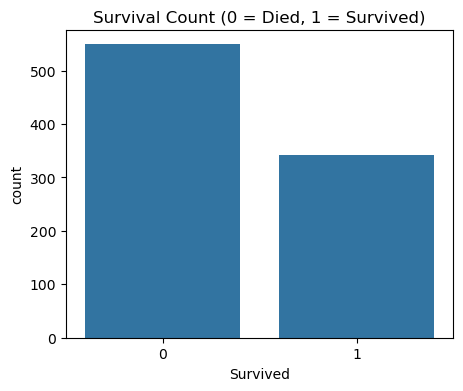

In [6]:
print(df["Survived"].value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.show()

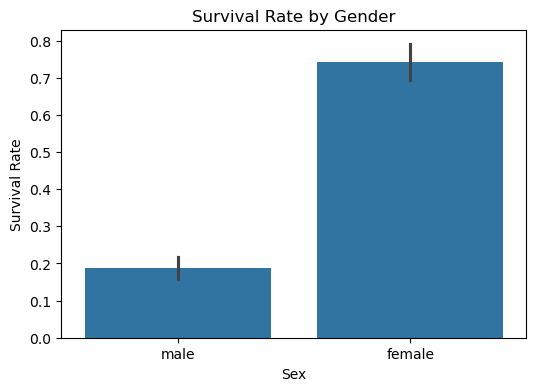

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

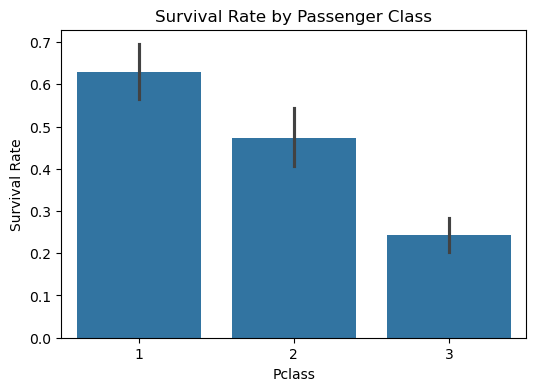

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

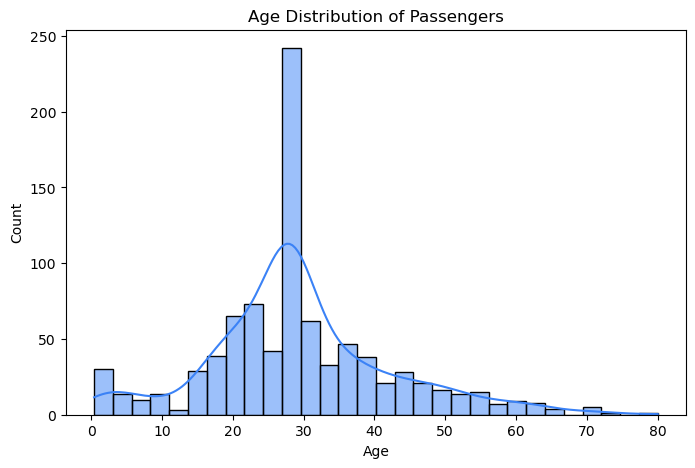

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="#3B82F6")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.show()

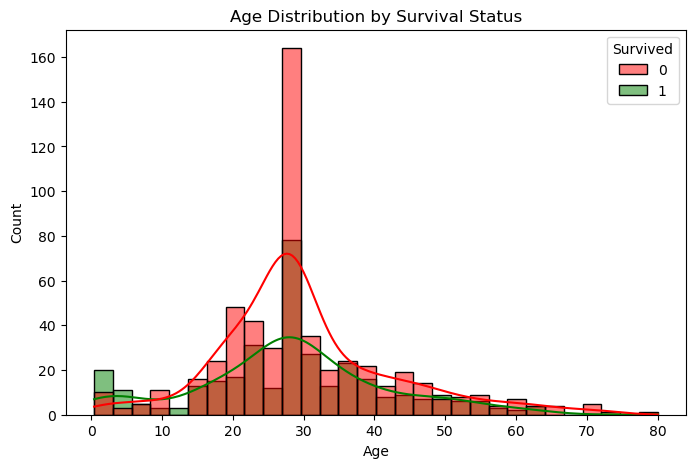

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, palette=["red","green"])
plt.title("Age Distribution by Survival Status")
plt.show()

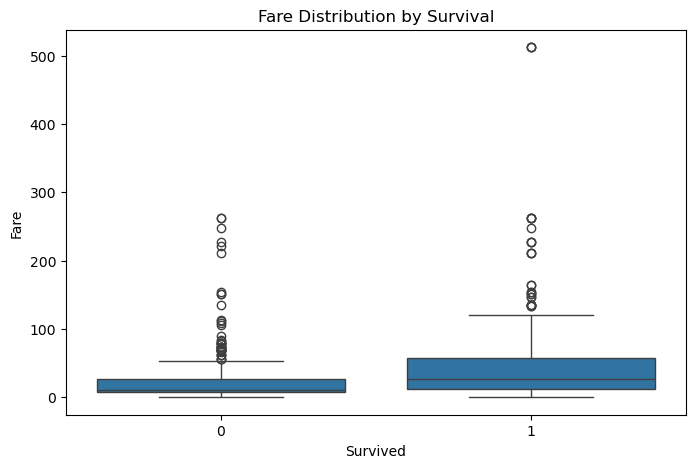

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.show()

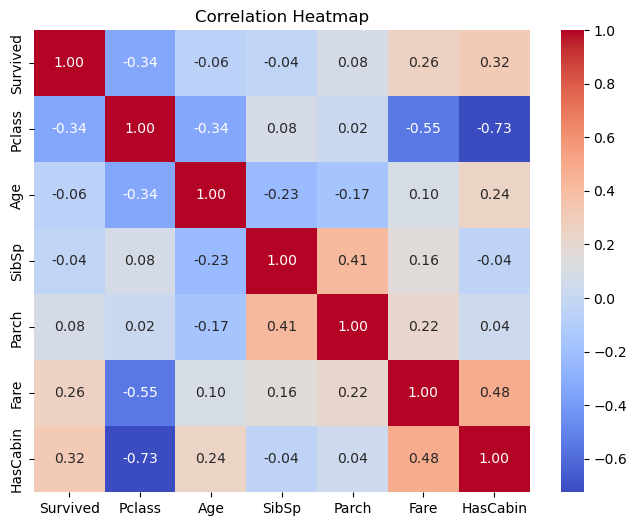

In [12]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

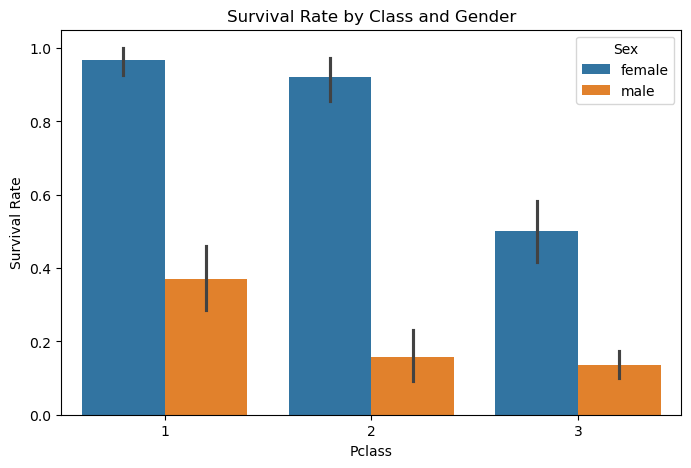

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.ylabel("Survival Rate")
plt.show()

In [ ]:
#women had a much higher survival rate than men; 1st class passengers survived at a higher rate than 3rd class; younger children had somewhat better survival odds; higher fares correlate with higher survival 